# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое
решающее дерево и сравните его со стандартное
имплементацией из sklearn. Вы также протестируете
деревья на более сложных датасетах и сравните различные
подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость»
(указана в скобках около задачи).
Максимально допустимая оценка за работу — 10 баллов.
Неэффективная и/или неоригинальная реализация кода
может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с
реализованными функциями и классами ```hw2code.py```
необходимо загрузить на свой Github. Затем нужно
оставить комментарий в Google-таблице с оценками в
столбце <<hw2>> в строке со своей фамилией о том, что
вы выполнили работу с указанием ника на Kaggle.

In [420]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_moons, make_circles, make_classification
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score
sns.set(style='whitegrid')

warnings.filterwarnings('ignore')

В этой части мы рассмотрим два простых двумерных
датасета сделанных с помощью `make_moons`,
`make_circles` и посмотрим как ведет себя
разделяющая поверхность в зависимости
от различных гиперпараметров.

In [421]:
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [422]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

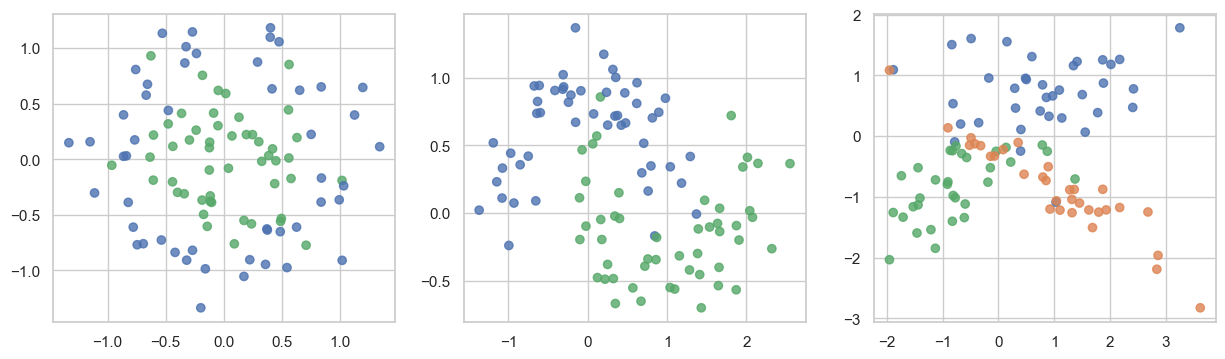

In [423]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево
с параметрами по умолчанию, предварительно разбив
выборку на обучающую и тестовую. Постройте
разделящие поверхности (для этого воспользуйтесь
функцией `plot_surface`, пример ниже). Посчитайте
accuracy на обучающей и тестовой выборках.
Сильно ли деревья переобучились?

In [424]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

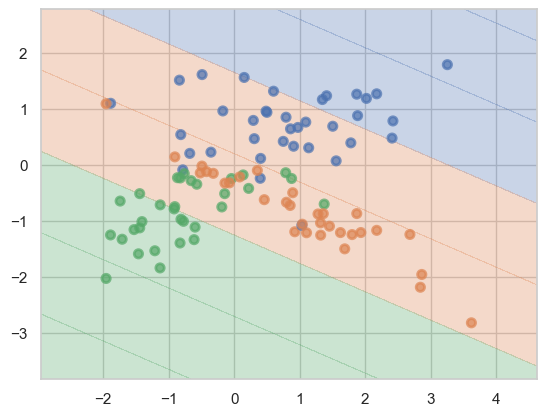

In [425]:
# Пример:
X, y = datasets[2]
lr = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

dataset 0:
	training 1.0000
	testing  0.7576
dataset 1:
	training 1.0000
	testing  0.8788
dataset 2:
	training 1.0000
	testing  0.8485


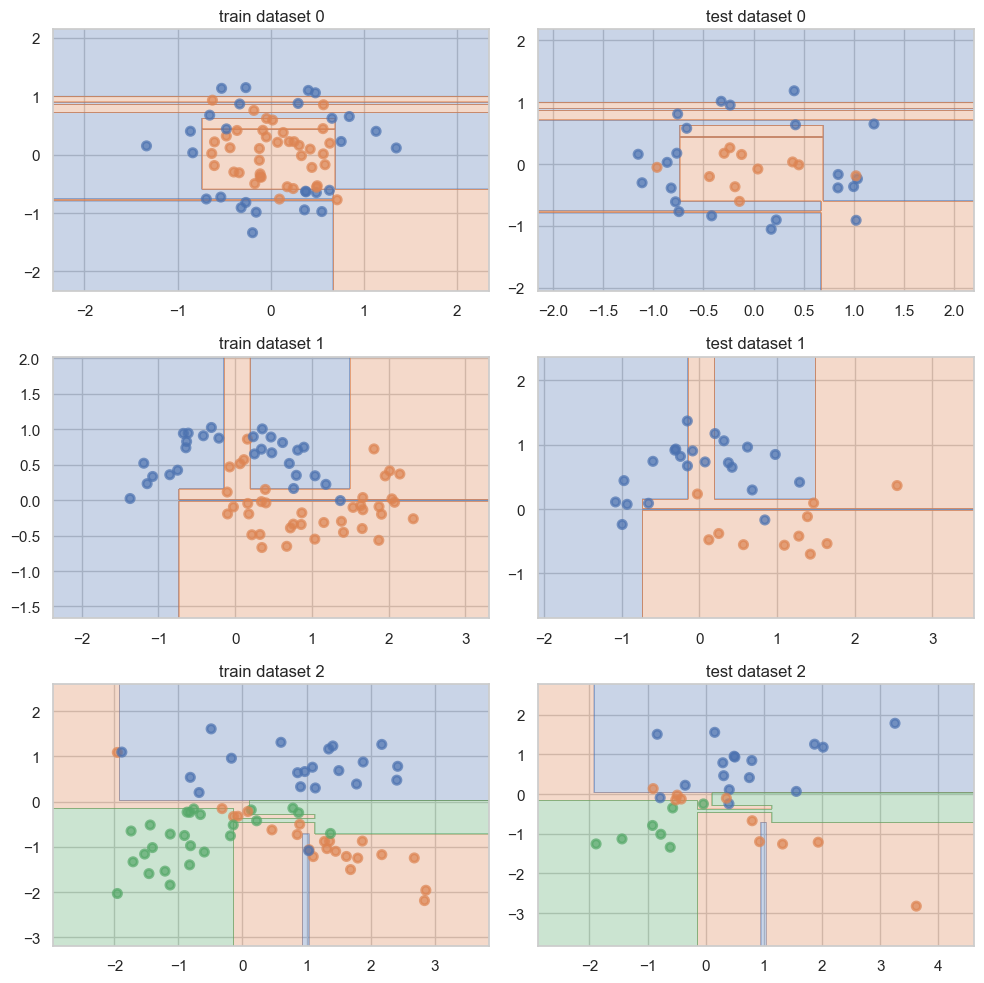

In [426]:
plt.figure(figsize=(10, 10))
trained_models_data = []
for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=42)

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_preds = clf.predict(X_train)
    test_preds = clf.predict(X_test)
    train_res = accuracy_score(y_train, train_preds)
    test_res = accuracy_score(y_test, test_preds)

    print(f"dataset {i}:")
    print(f"\ttraining {train_res:.4f}")
    print(f"\ttesting  {test_res:.4f}")
    
    plt.subplot(3, 2, 2 * i + 1)
    plt.title(f'train dataset {i}')
    plot_surface(clf, X_train, y_train)

    plt.subplot(3, 2, 2*i + 2)
    plt.title(f'test dataset {i}')
    plot_surface(clf, X_test, y_test)


plt.tight_layout()
plt.show()

__Ответ:__ деревья сильро переобучились

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для
регуляризации (напр. `max_depth`, `min_samples_leaf`).
Для каждого набора гиперпараметров постройте
разделяющую поверхность, выведите обучающую и
тестовую ошибки. Можно делать кросс-валидацию
или просто разбиение на трейн и тест, главное
делайте каждый раз одинаковое разбиение, чтобы
можно было корректно сравнивать (помните же, что
итоговое дерево сильно зависит от небольшого
изменения обучающей выборки?). Проследите как
меняется разделяющая поверхность и обобщающая
способность. Почему так происходит, одинаково ли
изменение для разных датасетов?

dataset 0: max_depth = None, min_samples_leaf = 1
	training 1.0000
	testing  0.7576
dataset 0: max_depth = None, min_samples_leaf = 2
	training 0.9403
	testing  0.8485
dataset 0: max_depth = None, min_samples_leaf = 3
	training 0.9403
	testing  0.7879
dataset 0: max_depth = 1, min_samples_leaf = 1
	training 0.7313
	testing  0.4848
dataset 0: max_depth = 1, min_samples_leaf = 2
	training 0.7313
	testing  0.4848
dataset 0: max_depth = 1, min_samples_leaf = 3
	training 0.7313
	testing  0.4848
dataset 0: max_depth = 3, min_samples_leaf = 1
	training 0.8806
	testing  0.7576
dataset 0: max_depth = 3, min_samples_leaf = 2
	training 0.8657
	testing  0.7879
dataset 0: max_depth = 3, min_samples_leaf = 3
	training 0.8806
	testing  0.7576
dataset 0: max_depth = 5, min_samples_leaf = 1
	training 0.9701
	testing  0.7879
dataset 0: max_depth = 5, min_samples_leaf = 2
	training 0.9403
	testing  0.8485
dataset 0: max_depth = 5, min_samples_leaf = 3
	training 0.9403
	testing  0.7879
dataset 1: max_dept

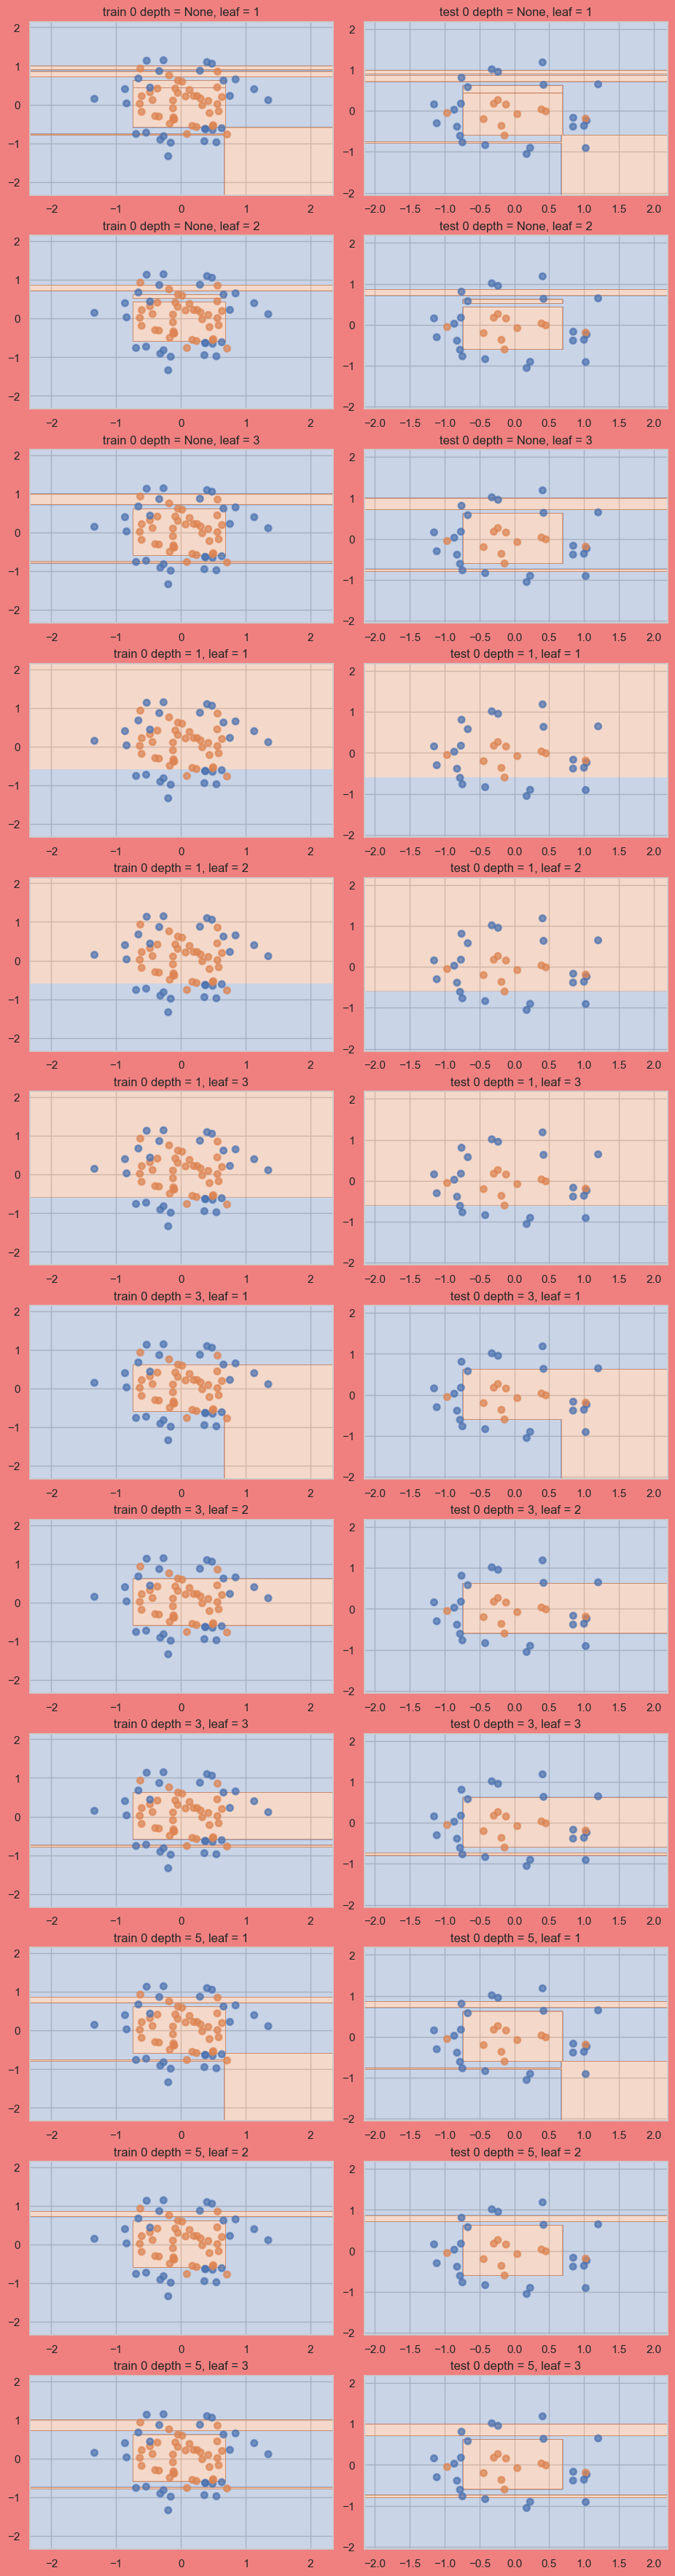

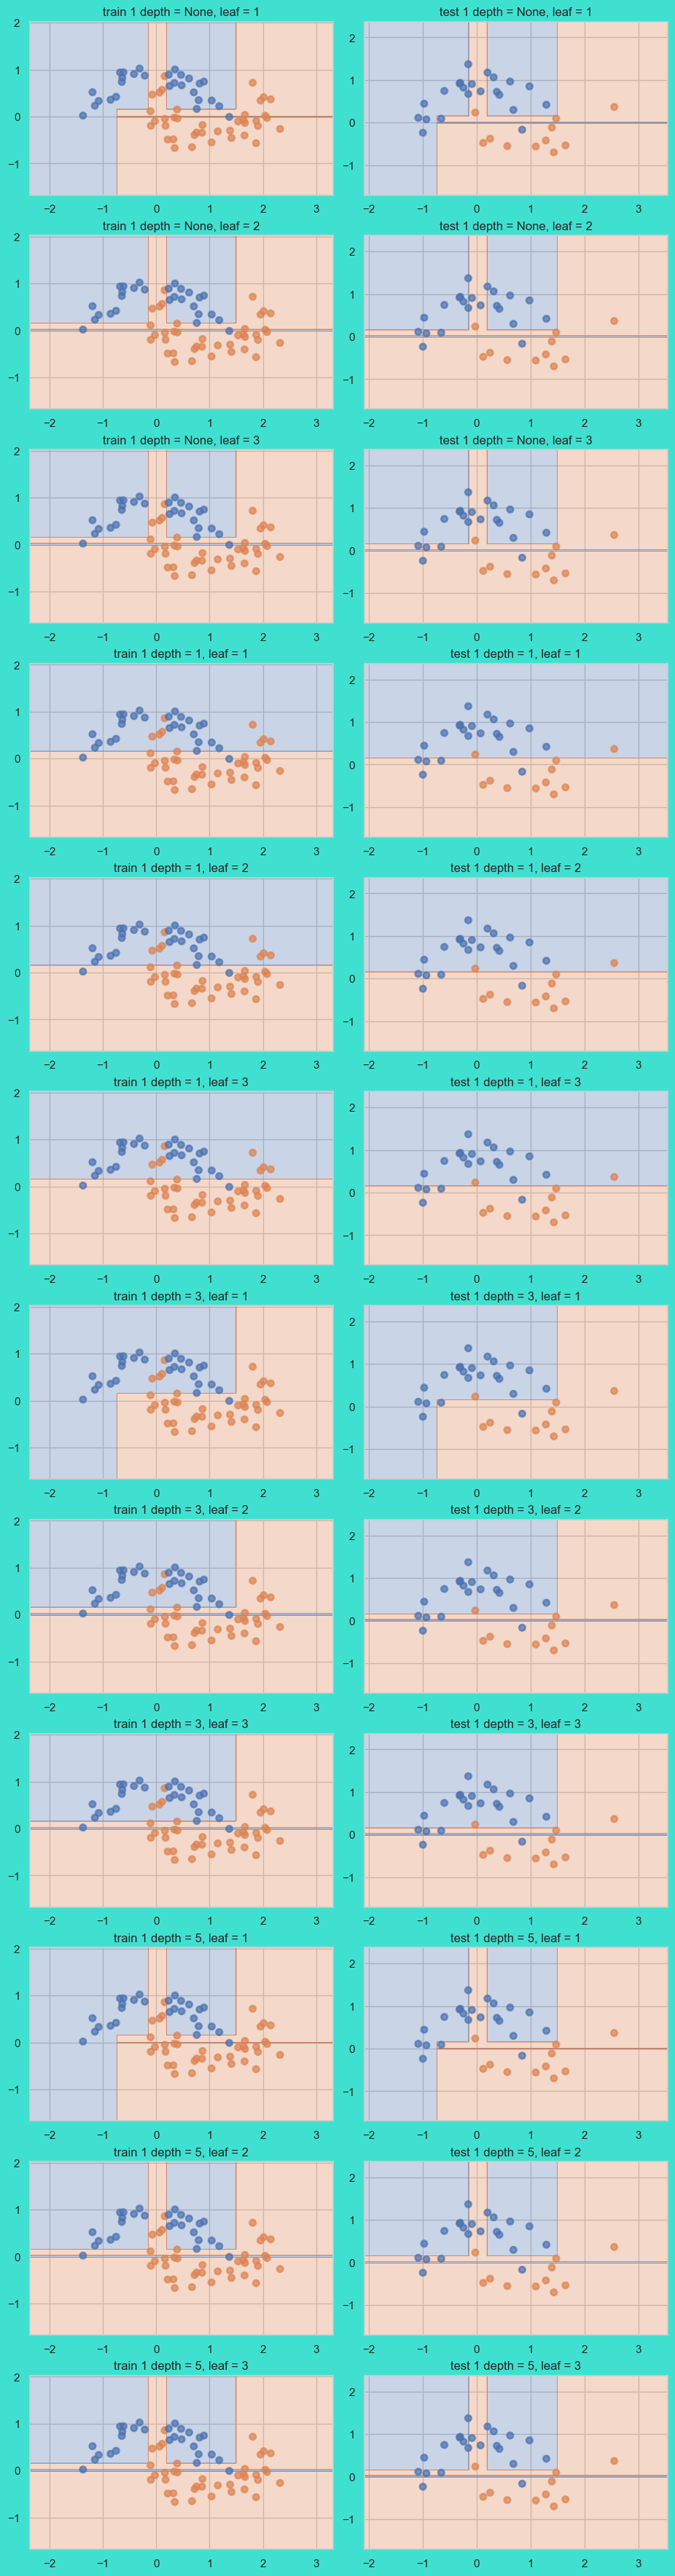

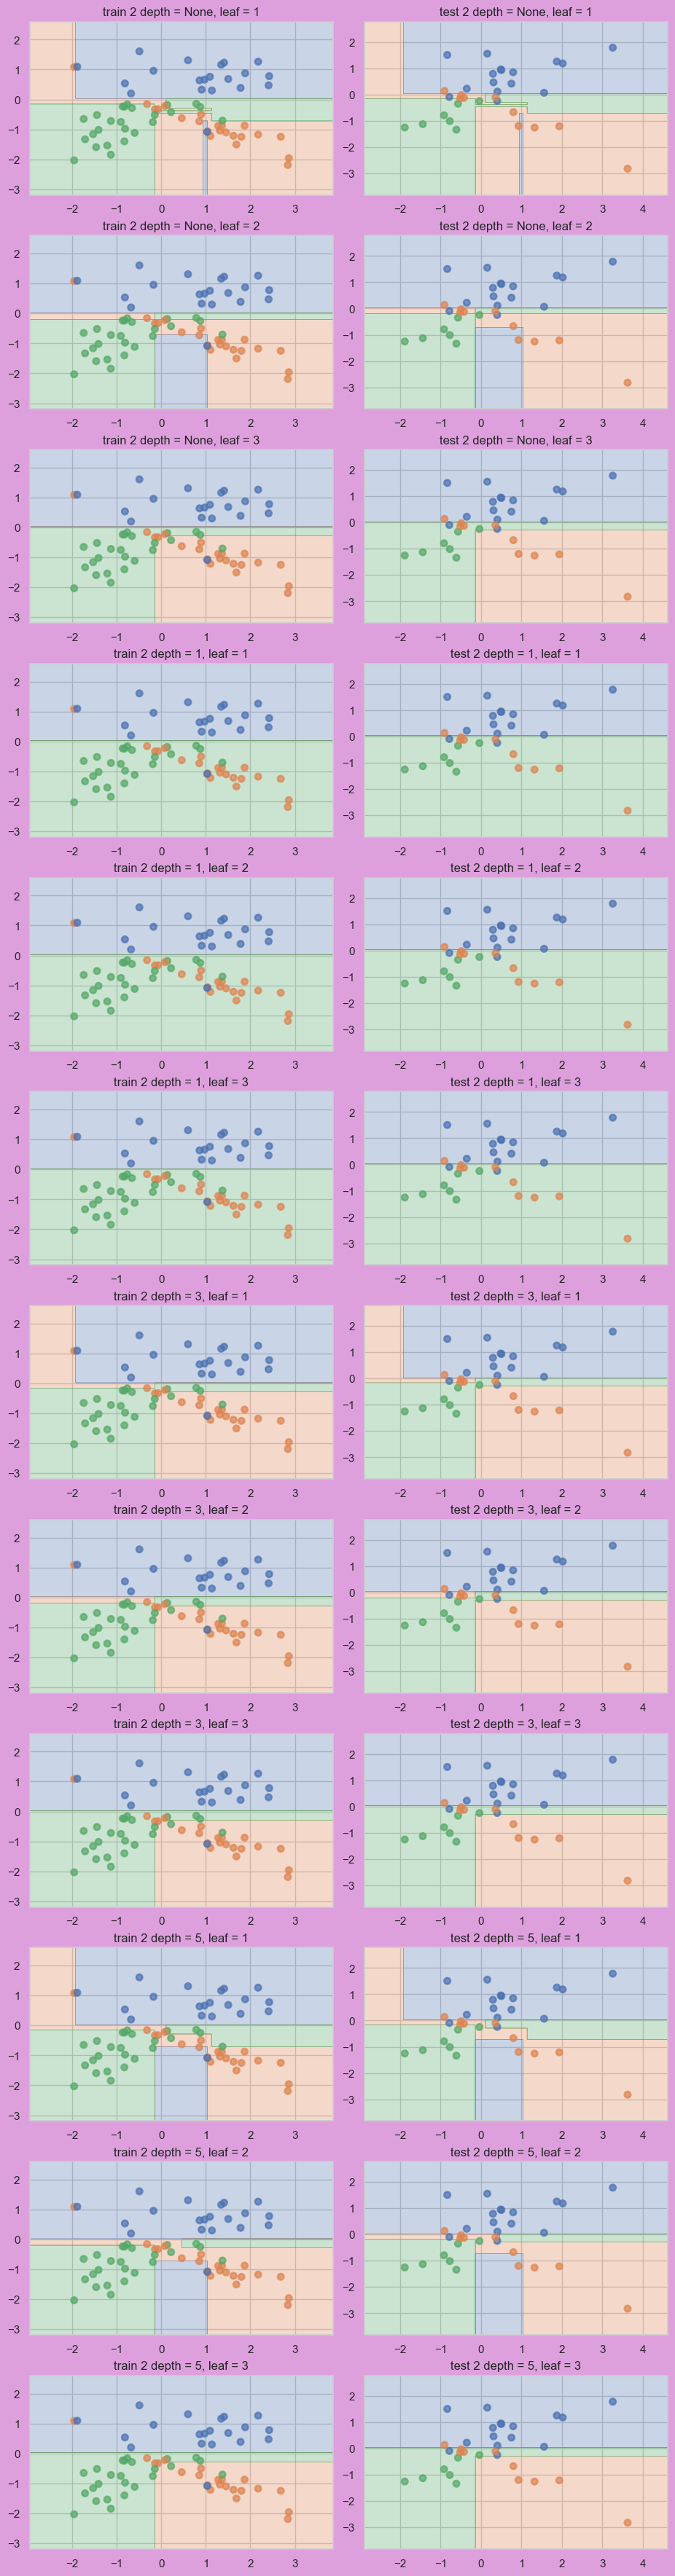

In [427]:
from itertools import product
max_depths = [None, 1, 3, 5]
min_samples_leaf = [1, 2, 3]
colors = ["lightcoral", "turquoise", "plum"]

dataset_cnt = len(max_depths) * len(min_samples_leaf)
for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42)
    fig = plt.figure(figsize=(10, 3 * dataset_cnt))
    fig.set_facecolor(color=colors[i])

    for j, (d, l) in enumerate(product(max_depths, min_samples_leaf)):
        clf = DecisionTreeClassifier(random_state=42,max_depth=d, min_samples_leaf=l)
        clf.fit(X_train, y_train)
        
        train_preds = clf.predict(X_train)
        test_preds = clf.predict(X_test)
        train_res = accuracy_score(y_train, train_preds)
        test_res = accuracy_score(y_test, test_preds)

        print(f"dataset {i}: max_depth = {d}, min_samples_leaf = {l}")
        print(f"\ttraining {train_res:.4f}")
        print(f"\ttesting  {test_res:.4f}")
        
        plt.subplot(dataset_cnt, 2, 2 * j + 1)
        plt.title(f'train {i} depth = {d}, leaf = {l}')
        plot_surface(clf, X_train, y_train)

        plt.subplot(dataset_cnt, 2, 2*j + 2)
        plt.title(f'test {i} depth = {d}, leaf = {l}')
        plot_surface(clf, X_test, y_test)

__Ответ:__ чем больше max_depths и чем меньше min_samples_leaf тем более сложными
являются решающие границы, что означает большую регулизацию. Из нее следуюет меньшая 
точность при обучении, и меньший шанс переобучения, что может привести к лучшей точности
на тестовой выборке

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс
для обучения решающего дерева в задаче бинарной
классификации с возможностью обработки вещественных
и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py
Под критерием Джини здесь подразумевается следующая функция:
$$Q(R) = -\frac {|R_l|}{|R|}H(R_l) -\frac {|R_r|}{|R|}H(R_r)$$
$R$ — множество объектов, $R_l$ и $R_r$ — объекты, попавшие в левое и правое поддерево,
    $H(R) = 1-p_1^2-p_0^2$, $p_1$, $p_0$ — доля объектов класса 1 и 0 соответственно.
  Указания:
 * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
* В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
* Поведение функции в случае константного признака может быть любым.
* При одинаковых приростах Джини нужно выбирать минимальный сплит.
* За наличие в функции циклов балл будет снижен. Векторизуйте! :)

:param feature_vector: вещественнозначный вектор значений признака
:param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)

:return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
 разделить на две различные подвыборки, или поддерева
:return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
:return threshold_best: оптимальный порог (число)
:return gini_best: оптимальное значение критерия Джини (число)

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет
[User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)).
В ней признаки объекта записаны в первых пяти
столбцах, а в последнем записана целевая
переменная (класс: 0 или 1). Постройте на одном
изображении пять кривых "порог — значение критерия
Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс"
для всех пяти признаков.

In [428]:
df = pd.read_csv("./datasets/students.csv")
df

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0
...,...,...,...,...,...,...
253,0.61,0.78,0.69,0.92,0.58,1
254,0.78,0.61,0.71,0.19,0.60,1
255,0.54,0.82,0.71,0.29,0.77,1
256,0.50,0.75,0.81,0.61,0.26,1


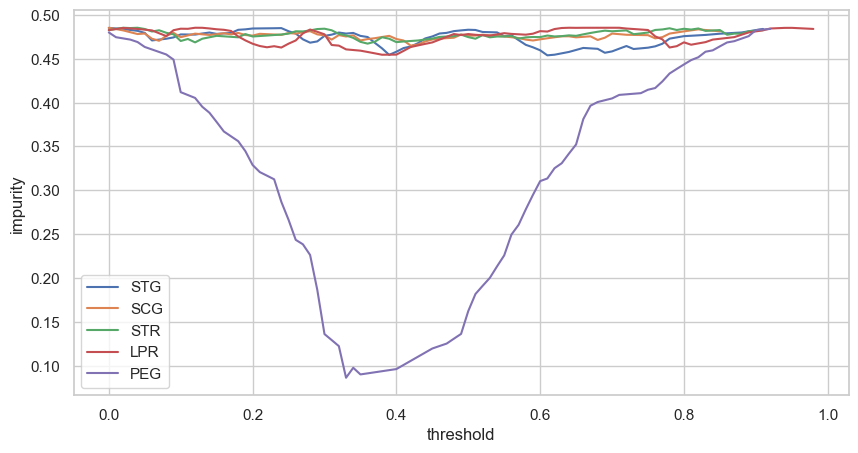

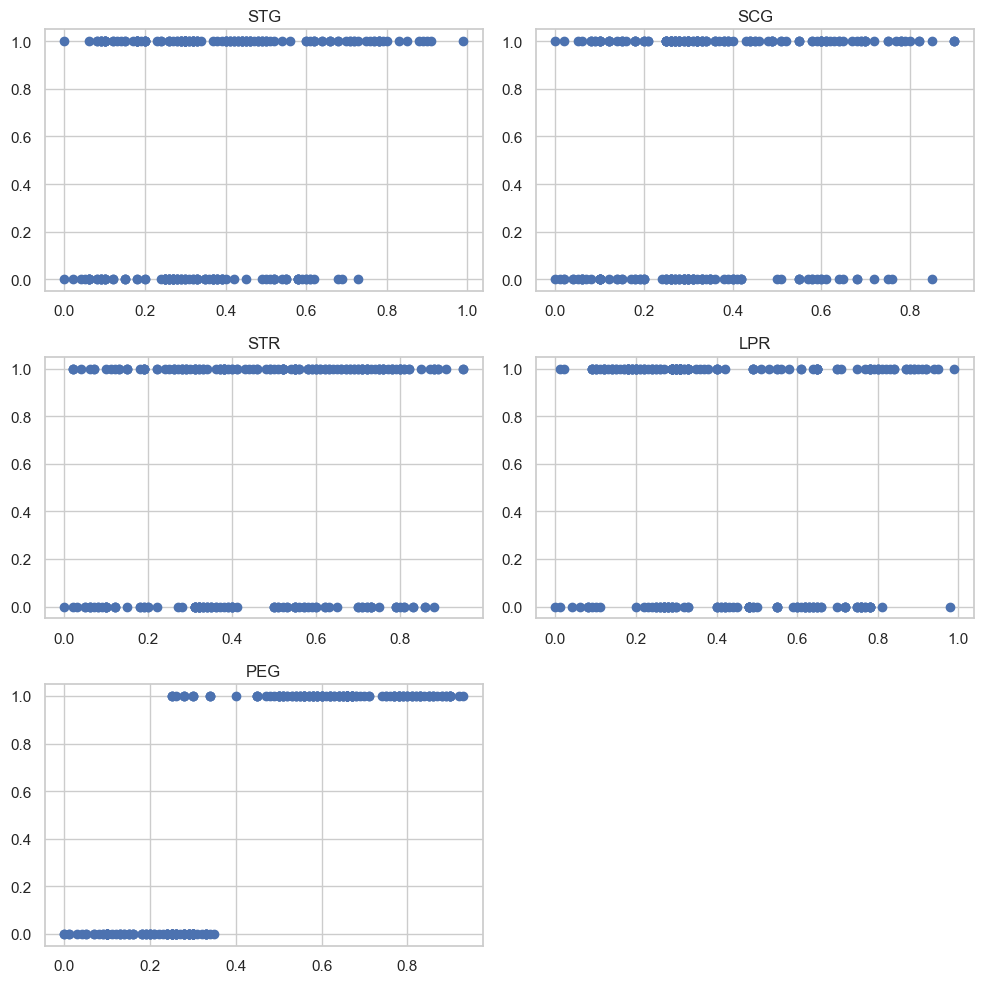

In [429]:
X = df.iloc[:, :5]
y = df.iloc[:, 5]

def gini_impurity(groups, classes):
    n_instances = float(sum([len(group) for group in groups]))
    gini = 0.0
    for g in groups:
        size = len(g)
        score = sum([((g == c).sum() / size) ** 2 for c in classes])
        gini += (1.0 - score) * (size / n_instances)
    return gini


plt.figure(figsize=(10, 5))

for feature in X.columns:
    vals = X[feature].values
    thresholds = np.sort(np.unique(vals))
    impurities = [gini_impurity([y[vals <= t], y[vals > t]], [0, 1]) for t in thresholds]
    plt.plot(thresholds, impurities, label=feature)

plt.xlabel('threshold')
plt.ylabel('impurity')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 10))

for i, feature in enumerate(X.columns):
    plt.subplot(3, 2, i + 1)
    plt.scatter(X[feature], y)
    plt.title(f'{feature}')
    plt.grid(True)

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому
признаку нужно производить деление выборки на два
поддерева? Согласуется ли этот результат с визуальной
оценкой scatter-графиков? Как бы охарактеризовали вид
кривой для "хороших" признаков, по которым выборка
делится почти идеально? Чем отличаются кривые для
признаков, по которым деление практически невозможно?

**Ответ:** Исходя из кривых деление стоит производить по признаку PEG.
Этот результат согласуется со scatter-шрафиками
Чем ниже минимум gini, тем лучше этот признак подходит для разбиения.
Кривая для хорошего признака дольжна иметь резкое падение. Кривые по которым
деление практически невозможно гораздо более ровные, не имеют резких падений

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода
\_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому
жадному алгоритму, предложенному в лекции. Выбор
лучшего разбиения необходимо производить по критерию
Джини. Критерий останова: все объекты в листе относятся
к одному классу или ни по одному признаку нельзя разбить
выборку. Ответ в листе: наиболее часто встречающийся
класс в листе. Для категориальных признаков выполняется
преобразование, описанное в лекции в разделе
«Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете
[mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).
Вам нужно скачать таблицу agaricus-lepiota.data
(лежит на гитхабе вместе с заданием), прочитать ее
с помощью pandas, применить к каждому столбцу
LabelEncoder (из sklearn), чтобы преобразовать строковые
имена категорий в натуральные числа. Первый столбец — это
целевая переменная (e — edible, p — poisonous) Мы будем
измерять качество с помощью accuracy, так что нам не
очень важно, что будет классом 1, а что — классом 0.
Обучите решающее дерево на половине случайно выбранных
объектов (признаки в датасете категориальные) и сделайте
предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное
единице (или очень близкое к единице), и не очень
глубокое дерево.

In [430]:
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('./datasets/agaricus-lepiota.data')
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
df

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
1,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
2,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
3,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
4,0,5,3,9,1,0,1,0,0,5,...,2,7,7,0,2,1,4,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8119,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8120,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8121,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


In [431]:
import hw2code
from importlib import reload
reload(hw2code)

<module 'hw2code' from '/Users/maxgiga/dev/mai/ml/hw2code.py'>

In [432]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42)
feature_types = ['categorical'] * X.shape[1]
X_train_vals = X_train.reset_index(drop=True).values
X_test_vals = X_test.reset_index(drop=True).values
y_train_vals = y_train.reset_index(drop=True).values
y_test_vals = y_test.reset_index(drop=True).values

tree = hw2code.DecisionTree(feature_types=feature_types)
tree.fit(X_train_vals, y_train_vals)
y_pred = tree.predict(X_test_vals)
accuracy_score(y_test_vals, y_pred)

1.0

__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров
max_depth, min_samples_split и min_samples_leaf по
аналогии с DecisionTreeClassifier. Постройте графики
зависимости качества предсказания в зависимости от этих
параметров для набора данных tic-tac-toe (см. следующий
пункт).

Text(0.5, 1.0, 'min_samples_split')

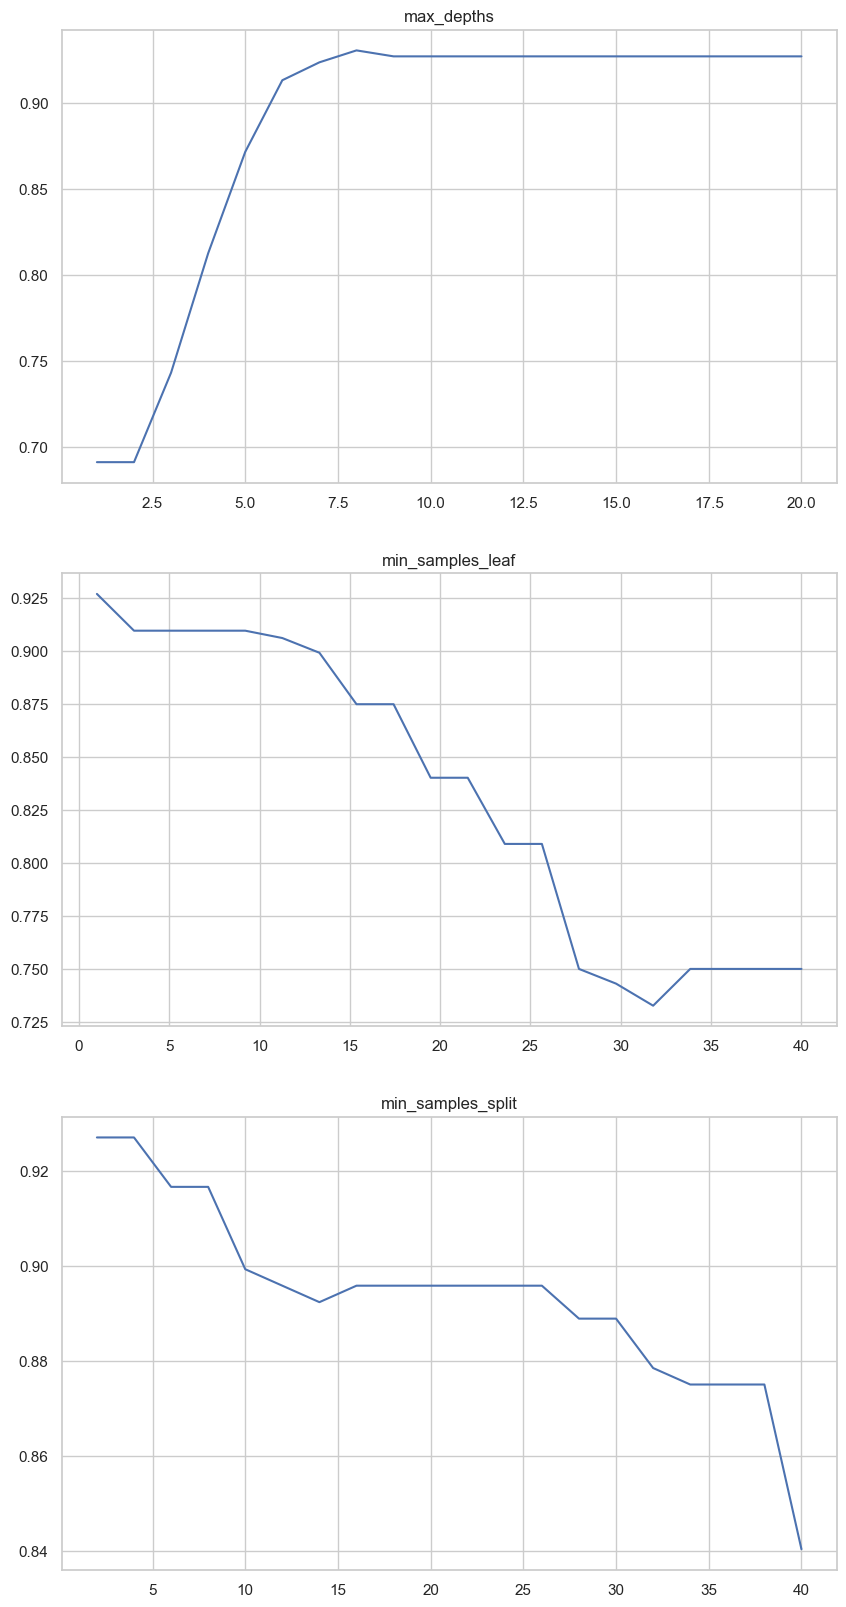

In [433]:
df = pd.read_csv("./datasets/tic-tac-toe-endgame.csv")
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.iloc[:, :9]
y = df.iloc[:, 9]
X_vals = X.reset_index(drop=True).values
y_vals = y.reset_index(drop=True).values

max_depths = np.linspace(1, 20, 20)
min_samples_leaf = np.linspace(1, 40, 20)
min_samples_split = np.linspace(2, 40, 20)

X_train, X_test, y_train, y_test = train_test_split(
        X_vals, y_vals, test_size=0.3, random_state=42)
feature_types = ['categorical'] * X.shape[1]


def train_with_data(max_depth, min_samples_leaf, min_samples_split):
    tree = hw2code.DecisionTree(feature_types=feature_types, 
                                max_depth=max_depth, 
                                min_samples_leaf=min_samples_leaf, 
                                min_samples_split=min_samples_split)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    return accuracy_score(y_test, y_pred)

plt.figure(figsize=(10, 20))

plt.subplot(3, 1, 1)
plt.plot(max_depths, [train_with_data(a, None, None) for a in max_depths])
plt.title("max_depths")

plt.subplot(3, 1, 2)
plt.plot(min_samples_leaf, [train_with_data(None, a, None) for a in min_samples_leaf])
plt.title("min_samples_leaf")

plt.subplot(3, 1, 3)
plt.plot(min_samples_split, [train_with_data(None, None, a) for a in min_samples_split])
plt.title("min_samples_split")

__Задание 9. (2 балла)__

Загрузите следующие наборы данных
(напомним, что pandas умеет загружать файлы по url,
в нашем случае это файл \*.data), предварительно
ознакомившись с описанием признаков и целевой переменной
в каждом из них (она записаны в Data Folder, в файле
*.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom)
(загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame)
(классы записаны в последнем столбце, датасет лежит на
гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation)
(классы записаны в последнем столбце, считаем
что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery)
(классы записаны в последнем столбце, считаем, что
not_recom и recommend — класс 0, very_recom, priority,
spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат
в pd.DataFrame (по строкам — наборы данных, по
столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно
передать scoring=make_scorer(accuracy_score),
обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего
позволяет), указывайте параметр sparse=False в
OneHotEncoder (если вы, конечно, используете его).
Иначе вам придется добиваться того, чтобы ваша
реализация дерева умела работать с разреженными
матрицами (что тоже, в целом, не очень сложно).

In [434]:
datasets = []

le = LabelEncoder()
df = pd.read_csv("./datasets/agaricus-lepiota.data")
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
datasets.append((X, y, "mushrooms"))

df = pd.read_csv("./datasets/tic-tac-toe-endgame.csv")
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.iloc[:, :9]
y = df.iloc[:, 9]
datasets.append((X, y, "tic-tac-toe"))

df = pd.read_csv("./datasets/car.data")
mapping = {"unacc": 0, "acc": 0, "good": 1, "vgood": 1}
df.iloc[:, 6] = df.iloc[:, 6].apply(lambda x: mapping[x])
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.iloc[:, :6]
y = df.iloc[:, 6]
datasets.append((X, y, "car"))

df = pd.read_csv("./datasets/nursery.data")
mapping = {"not_recom": 0, "recommend": 0, "very_recom": 1, "priority": 1, "spec_prior": 1}
df.iloc[:, 8] = df.iloc[:, 8].apply(lambda x: mapping[x])
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.iloc[:, :8]
y = df.iloc[:, 8]
datasets.append((X, y, "nursery"))

In [436]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

scorer = make_scorer(accuracy_score)

for X, y, name in datasets:
    X_vals = X.reset_index(drop=True).values
    y_vals = y.reset_index(drop=True).values

    feature_real = ['real'] * X_vals.shape[1]
    tree_real = hw2code.DecisionTree(feature_types=feature_real)
    scores_real = cross_val_score(tree_real, X_vals, y_vals, cv=10, scoring=scorer)

    feature_cat = ['categorical'] * X_vals.shape[1]
    tree_cat = hw2code.DecisionTree(feature_types=feature_cat)
    scores_cat = cross_val_score(tree_cat, X_vals, y_vals, cv=10, scoring=scorer)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X_vals)
    feature_real = ['real'] * X_ohe.shape[1]
    tree_ohe = hw2code.DecisionTree(feature_types=feature_real)
    scores_ohe = cross_val_score(tree_ohe, X_ohe, y_vals, cv=10, scoring=scorer)

    tree_sk = DecisionTreeClassifier(random_state=42)
    scores_sk = cross_val_score(tree_sk, X, y, cv=10, scoring=scorer)

    print(f"{name}")
    print(f"\treal:            {scores_real.mean():.4f}")
    print(f"\tcategorical:     {scores_cat.mean():.4f}")
    print(f"\tone hot encoder: {scores_ohe.mean():.4f}")
    print(f"\tsklearn tree:    {scores_sk.mean():.4f}")

mushrooms
	real:            0.9993
	categorical:     1.0000
	one hot encoder: 0.9996
	sklearn tree:    0.9620
tic-tac-toe
	real:            0.4675
	categorical:     0.5415
	one hot encoder: 0.5436
	sklearn tree:    0.7717
car
	real:            0.9426
	categorical:     0.9675
	one hot encoder: 0.9218
	sklearn tree:    0.9444
nursery
	real:            0.9998
	categorical:     0.9999
	one hot encoder: 0.9998
	sklearn tree:    0.9998


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:** Алгоритмы ранжируются по разному для разных наборов данных. DecisionTree хорошо работает для всех наборов, кроме tic-tac-toe, в котором собственная версия алгоритма показывает низкий результат: 0.46 для вещественного и 0.54 для категориального. При этом DecisionTreeClassifier из sklearn также показывает низкий результат 0.77
в сравнении с другими наборами, где он всегда больше 0.94. Это показывает, что
датасет tic-tac-toe плохо подходит для обработки деревом решений.
дерево решений принимающее все значения как вещественные работает хуже чем если принимать все значения как качественные. Этого следовало ожидать, так как используемые алгоритмы расчитаны на категориальные данные.

Вставьте что угодно, описывающее ваши впечатления от этого задания: